In [177]:
import matplotlib.pyplot as plt
from torch import nn
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import math
import warnings
import torchvision
import numpy as np
from scipy import interpolate
from scipy.optimize import minimize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import SplineTransformer
from collections import OrderedDict


In [178]:
def sim_data(n, dim, Type):
	if Type == 'A':
		X = torch.rand((n,2))
		y = torch.exp(2*torch.sin(X[:,0]*0.5*torch.pi)+ 0.5*torch.cos(X[:,1]*2.5*torch.pi))
		y = y.reshape(-1,1)
		y = y.float()
		
	elif Type == 'B':
		X = torch.rand((n, dim))
		y = 1
		for d in range(dim):
			a = (d+1)/2
			y *= ((torch.abs(4*X[:,d]-2)+a)/(1+a))
		y = y.reshape(-1,1)
		y = y.float()
	else:
		pass
	
	return X, y

ndim = 2
torch.manual_seed(0)
X_train, y_train = sim_data(400, ndim, 'A')
X_test, y_test = sim_data(400, ndim, 'A')
epstrain = torch.normal(0, 0.1, size=y_train.size())
epstest = torch.normal(0, 0.1, size=y_test.size())

y_train, y_test = y_train + epstrain, y_test + epstest

In [179]:
import torch
import torch.nn as nn

class NormLayer(nn.Module):
    def __init__(self):
        super(NormLayer, self).__init__()

    def forward(self, x):
        min_val = torch.min(x, dim=1, keepdim=True).values
        max_val = torch.max(x, dim=1, keepdim=True).values
        
        x = (x - min_val) / (max_val - min_val + 1e-6)
        return x

class BSL(nn.Module):
    def __init__(self, degree, num_knots, num_neurons, bias = True):
        super(BSL, self).__init__()
        self.degree = degree
        self.num_knots = num_knots
        self.num_neurons = num_neurons
        self.control_p = nn.Parameter(torch.randn(self.num_knots, self.num_neurons))
        
        if bias:
            self.bias = nn.Parameter(torch.randn(self.num_neurons))
        else:
            self.register_parameter('bias', None)
            
        self.inter = {}


    def knots_distribution(self, dg, nk):

        '''
        knots = torch.cat([torch.linspace(0, 0.001, steps=dg),            # Add repeated values at the start for clamping
            torch.linspace(0.002, 0.998, nk-1*dg-2),  # Uniform knot spacing in the middle
            torch.linspace(0.999, 1.000, steps=dg)           # Add repeated values at the end for clamping
            ]).view(-1,1)
        '''
        
        knots = torch.linspace(0.000, 1.000, nk-2).view(-1,1)
        return knots
    
    def basis_function(self, x, spl):
        basis_output = spl.fit_transform(x.detach().numpy())
        return basis_output
            
    def forward(self, x):
        batch_size, num_features = x.size()
        device = x.device
        
        # Create knot vector and apply B-spline basis functions for each feature
    
        basises = []
        knots = self.knots_distribution(self.degree, self.num_knots)
        #knots = knots.to(device)
        spl = SplineTransformer(n_knots=self.num_knots, degree=self.degree, knots = knots)

        
        for feature in range(num_features):
            # Calculate B-spline basis functions for this feature
            
            basis = self.basis_function(x[:, feature].reshape(-1,1), spl)
            basis = torch.Tensor(basis).to(device)
            basises.append(basis)
        
        print(len(basises), basises[0].size())
        self.inter['basic'] = torch.reshape(torch.stack(basises, dim = 1), (batch_size, self.num_knots * self.num_neurons)).T
        basises = torch.stack(basises)
        tout = basises.permute(1,2,0) * self.control_p
        tout = tout.sum(dim =1)
        if self.bias is not None:
            tout += self.bias        
            
        return tout 
    
class BSpline_block(nn.Module):
    def __init__(self, degree, num_knots, num_neurons, dropout = 0.0, bias = True):
        super(BSpline_block, self).__init__()

        self.block = nn.Sequential(OrderedDict([
            ('norm', NormLayer()),
            ('BSL', BSL(degree = degree, num_knots = num_knots, num_neurons = num_neurons, bias = bias)),
            ('drop', nn.Dropout(dropout)),
        ]))
        
    def forward(self, x):
        return self.block(x)
    
class StackBS_block(nn.Module):
    def __init__(self, block, degree, num_knots, num_neurons, num_blocks, dropout = 0.0, bias = True):
        super().__init__()
        self.model = nn.ModuleDict({
            f'block_{i}': block(degree = degree, num_knots = num_knots, num_neurons = num_neurons)
            for i in range(num_blocks)
        })

    def forward(self, x):
        for name, block in self.model.items():
            x = block(x)
        return x
    
class DPS(nn.Module):
    def __init__(self, input_dim, degree, num_knots, num_neurons, num_bsl, dropout, output_dim, bias):
        super(DPS, self).__init__()
        self.num_neurons = num_neurons
        self.num_knots = num_knots
        self.ln1 = nn.Linear(input_dim, num_neurons)
        self.Spline_block = StackBS_block(BSpline_block, degree = degree, num_knots = num_knots, num_neurons = num_neurons, num_blocks = num_bsl, dropout = dropout)
        self.ln2 = nn.Linear(num_neurons, output_dim)
        
    def forward(self, x):
        
        x = self.ln1(x)
        spout = self.Spline_block(x)
        output = self.ln2(spout)
        
        return output

    def get_para_ecm(self, x):

        '''
        ecm_para: A dictionary that collects the parameter we need to the following ECM algorithm.
        ecm_para.basic: Store the output of each B-Spline block; Dimension = [n_sample, n_neurons]
        ecm_para.ebasic Store the weight matrix of each B-Spline expansion; Dimension = [n_knots * n_neurons, n_sample]

        '''
        ecm_para = {}
        bs_block_out = {}
        bs_spline_weight = {}
        bs_spline_value = {}
        bs_spline_bias = {}

        _ = self(x)
        
        def get_activation(name):
            def hook(model, input, output):
                bs_block_out[name] = output.detach()
            return hook

        handles = []
        for name, layer in self.named_modules():
            if 'block.drop' in name:
                handles.append(layer.register_forward_hook(get_activation(name)))
            elif 'block.BSL' in name:
                bs_spline_value[name] = layer.inter['basic'].detach()
                bs_spline_weight[name] = layer.control_p.detach()
                bs_spline_bias[name] = layer.bias.detach()
        # Run forward pass (triggers hooks)
        _ = self(x)

        # Clean up hooks
        for h in handles:
            h.remove()
            
        ecm_para['basic'] = torch.stack(list(bs_block_out.values()), dim=0)
        ecm_para['ebasic'] = torch.stack(list(bs_spline_value.values()), dim=0)
        ecm_para['wbasic'] = torch.stack(list(bs_spline_weight.values()), dim=0)
        ecm_para['bbasic'] = torch.stack(list(bs_spline_bias.values()), dim=0)
        del bs_block_out, bs_spline_weight, bs_spline_value, bs_spline_bias
        
        return ecm_para

    def fit(self, x):
        return 0
    
def num_para(model):
    tp = 0
    for param in model.parameters():
        tp += param.numel()
    return tp

In [180]:
nk = 15; nm = 50; nl = 2; Fout = 1; device = "cpu"
model = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = nm, num_bsl = nl, dropout = 0.0, output_dim = Fout, bias = True).to(device)
print('Number of Parameters: ', num_para(model))

learning_r = 1e-1
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters(), lr=learning_r)
Iteration = 10000; bloss_list = []; tor = 1e-5; lr_tor = 1e-6
patientc = 10; patientr = 5; tpat = 0; bloss = np.inf

Number of Parameters:  1801


In [181]:
for t in range(Iteration):
    model.train()
    # Forward pass: Compute predicted y by passing x to the modelsp
    pyb_af = model(X_train)
    loss = criterion(y_train, pyb_af); bloss_list.append(loss.item())
    
    if (t > 0) and ((bloss_list[t-1]-bloss_list[t])<tor):        
        if (tpat != 0) and (tpat != 0) and (tpat % patientr) == 0:
            learning_r *= 0.2 
            tpat += 1
            #print('Learning rate reduce to ', learning_r)
            optimizer = torch.optim.Adam(model.parameters(), lr=learning_r)
            if learning_r <= lr_tor:
                print('Convergence!')
                break
        elif tpat < patientc:
            tpat += 1
            pass
        else:
            print('Convergence!')
            break
        
    else:
        if loss < bloss:
            #print('Current loss: ', loss.item(), ' | , previous best loss: ', bloss, ' | saving best model ...')
            torch.save(model.state_dict(), './EXB'+str(X_train.size()[0])+'h'+str(nm)+'k'+str(nk))
            bloss = loss.item()
            tpat = 0
        else:
            tpat += 1

    if tpat == patientc:
        print('Convergence!')
        break
        
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('| Epoch: ',t+1,'/',str(Iteration),' | Loss: ', np.round(loss.item(), 4),' |')

50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  1 / 10000  | Loss:  41.8502  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  2 / 10000  | Loss:  10.0686  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  3 / 10000  | Loss:  20.1749  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  4 / 10000  | Loss:  17.3715  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  5 / 10000  | Loss:  9.0784  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  6 / 10000  | Loss:  7.0821  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  7 / 10000  | Loss:  9.5681  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  8 / 10000  | Loss:  9.9743  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  9 / 10000  | Loss:  7.0888  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  10 / 10000  | Loss:  3.727  |
50 torch.Size([400, 15])
50 torch.Size([400, 15])
| Epoch:  11 / 10000  | Loss:  2.8631  |
50 to

50 torch.Size([400, 15])
50 torch.Size([400, 15])
50 torch.Size([400, 15])
50 torch.Size([400, 15])
(Train) MSPE:  tensor(0.0179) | (Test) MSPE:  tensor(0.0451)
50 torch.Size([400, 15])
50 torch.Size([400, 15])
50 torch.Size([400, 15])
50 torch.Size([400, 15])


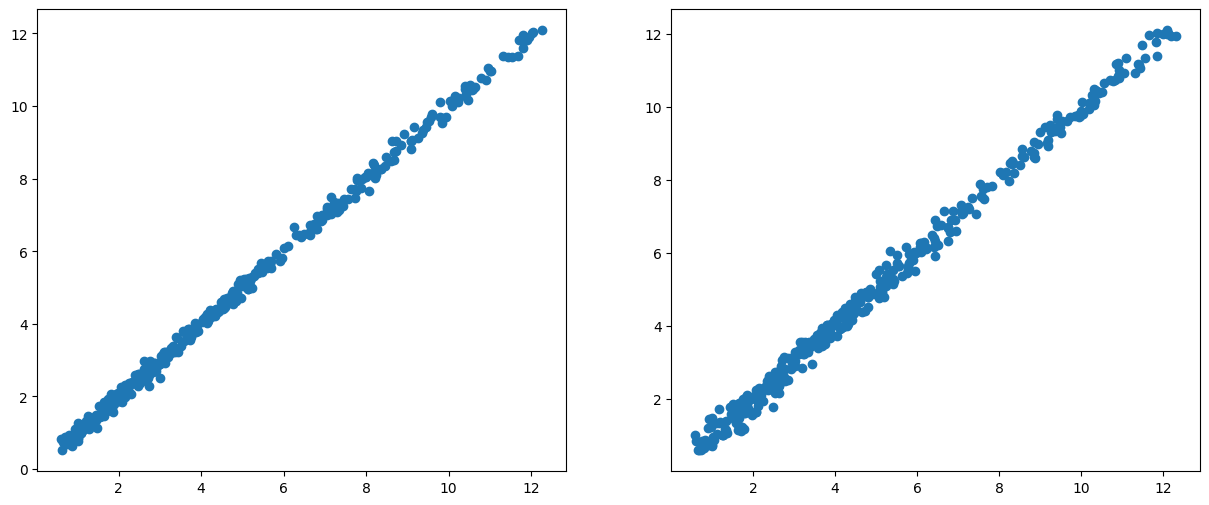

In [182]:
with torch.no_grad():
    eval_model = DPS(input_dim = ndim, degree = 3, num_knots = nk, num_neurons = nm, num_bsl = nl, dropout = 0.0, output_dim = Fout, bias = True).to(device)
    eval_model.load_state_dict(torch.load('./EXB'+str(X_train.size()[0])+'h'+str(nm)+'k'+str(nk), weights_only = True))
    eval_model.eval()
    print('(Train) MSPE: ',criterion(y_train, eval_model(X_train).detach()), '| (Test) MSPE: ',criterion(y_test, eval_model(X_test).detach()))
    plt.figure(figsize=(15,6))
    plt.subplot(1,2,1)
    plt.scatter(y_train, eval_model(X_train).detach())
    plt.subplot(1,2,2)
    plt.scatter(y_test, eval_model(X_test).detach())

torch.Size([400, 2])

In [ ]:
400*19

380000

## ECM Testing

In [ ]:
B = eval_model.get_para_ecm(X_train)['ebasic']
By = eval_model.get_para_ecm(X_train)['basic']


In [146]:
import torch
import torch.nn as nn

class LayerWise_ECM_GCV_Tuner:
    """
    針對 Deep P-Spline 的每一層獨立計算最佳 Lambda。
    結合 ECM (Expectation Conditional Maximization) 與 GCV (Generalized Cross Validation)。
    """
    def __init__(self, num_knots, order=2, device='cuda'):
        self.num_knots = num_knots
        self.order = order
        self.device = device
        # 預先建立懲罰矩陣 P
        self.P = self._build_penalty_matrix(num_knots, order).to(device)

    def _build_penalty_matrix(self, k, order):
        """建構 k x k 的差分懲罰矩陣 P = D^T D"""
        if order == 0: return torch.eye(k)
        D = torch.zeros(k - order, k)
        if order == 1:
            for i in range(k - 1):
                D[i, i], D[i, i + 1] = -1, 1
        elif order == 2:
            for i in range(k - 2):
                D[i, i], D[i, i + 1], D[i, i + 2] = 1, -2, 1
        return torch.matmul(D.T, D)

    def fit_layers(self, basis_matrix, target, max_iter=20, tol=1e-4):
        """
        Args:
            basis_matrix: [Layers, Neuron*Knots, Batch]
            target:       [Layers, Batch, Neuron]
        
        Returns:
            best_lambdas: list of float, 每一層的最佳 lambda
            final_thetas: list of Tensor, 每一層的係數 [Neuron, Knot]
        """
        num_layers = basis_matrix.shape[0]
        batch_size = basis_matrix.shape[2]
        num_neurons = target.shape[2]
        
        best_lambdas = []
        final_thetas = []

        print(f"Starting Tuning for {num_layers} layers...")

        for l in range(num_layers):
            # 1. 準備該層數據 & 重塑
            # Basis: [N*K, B] -> Transpose -> [B, N*K] -> View -> [B, N, K]
            B_l = basis_matrix[l].T.view(batch_size, num_neurons, self.num_knots).to(self.device)
            # Target: [B, N] -> [B, N, 1]
            y_l = target[l].unsqueeze(-1).to(self.device)

            # 2. 預計算統計量 (大幅加速 ECM)
            # 我們需要對 Batch 維度求和，得到每個 Neuron 的 Gram Matrix
            # G[n] = sum_b ( B[b,n].T @ B[b,n] ) -> Shape: [N, K, K]
            # R[n] = sum_b ( B[b,n].T @ y[b,n] ) -> Shape: [N, K, 1]
            
            # 使用 einsum 高效計算
            # b: batch, n: neuron, i: knot_i, j: knot_j
            print(f"  > Layer {l}: Pre-computing Gram matrices...")
            BTB_all = torch.einsum('bni,bnj->nij', B_l, B_l) 
            BTy_all = torch.einsum('bni,bnj->nij', B_l, y_l)
            yTy_total = torch.sum(y_l ** 2).item() # Total Sum of Squares (Scalar)
            
            # 釋放原始的大矩陣 B_l 以節省顯存
            del B_l, y_l
            torch.cuda.empty_cache()

            # 3. 執行 ECM + GCV 循環
            best_lam, best_theta = self._run_ecm_single_layer(
                BTB_all, BTy_all, yTy_total, 
                batch_size * num_neurons, # Total samples count
                max_iter, tol
            )
            
            best_lambdas.append(best_lam)
            final_thetas.append(best_theta)
            print(f"  > Layer {l} Done. Best Lambda: {best_lam:.6f}")

        return best_lambdas, final_thetas

    def _run_ecm_single_layer(self, BTB, BTy, yTy_scalar, n_total_obs, max_iter, tol):
        """
        針對單一層執行 ECM 並追蹤最小 GCV。
        所有輸入張量維度皆為 [Neurons, K, K] 或 [Neurons, K, 1]。
        這利用了 PyTorch 的 Batch Linear Algebra 進行並行計算。
        """
        num_neurons = BTB.shape[0]
        K = self.num_knots
        
        # 初始化 lambda
        curr_lambda = torch.tensor(1.0, device=self.device)
        
        # 記錄最佳狀態
        min_gcv = float('inf')
        best_lambda_val = 1.0
        best_theta = None
        
        # 加上 Jitter 保持數值穩定
        jitter = 1e-6 * torch.eye(K, device=self.device).unsqueeze(0) # [1, K, K]
        BTB_stable = BTB + jitter

        for i in range(max_iter):
            # --- E-Step: 更新係數 Theta (每個 Neuron 獨立並行) ---
            # H = B^T B + lambda * P
            # P 擴展為 [1, K, K] 進行廣播
            P_expanded = self.P.unsqueeze(0)
            H = BTB_stable + curr_lambda * P_expanded # Shape: [N, K, K]
            
            # 解 H * theta = B^T y
            # 使用 cholesky_solve 比 inverse 快且穩
            try:
                L = torch.linalg.cholesky(H)
                theta = torch.cholesky_solve(BTy, L) # Shape: [N, K, 1]
            except:
                # Fallback if specific lambda makes H non-positive definite
                theta = torch.linalg.solve(H, BTy)
                # 對 L 做近似以計算 trace
                L = torch.linalg.cholesky(H + 1e-4 * torch.eye(K, device=self.device))

            # --- 計算有效自由度 (EDF) ---
            # EDF_j = trace( H_j^-1 * BTB_j )
            # 為了效率，我們使用 cholesky_inverse 算出 H_inv
            H_inv = torch.cholesky_inverse(L)
            
            # Trace(A @ B) = sum(A * B.T) element-wise
            # 這裡我們計算 neuron 級別的 EDF
            edfs = torch.sum(H_inv * BTB_stable, dim=(1, 2)) # [N]
            total_edf = torch.sum(edfs) # 純量: 整層的總 EDF

            # --- M-Step: 準備統計量 (Aggregation) ---
            
            # 1. 總殘差平方和 (Total RSS)
            # RSS = y'y - 2 theta' B'y + theta' (B'B) theta
            # 這裡利用矩陣運算展開計算，避免重建 residuals
            # term2 = 2 * theta^T * BTy
            term2 = 2 * torch.sum(theta * BTy)
            # term3 = theta^T * BTB * theta
            term3 = torch.sum(theta * torch.matmul(BTB, theta))
            
            total_rss = yTy_scalar - term2 + term3
            total_rss = torch.clamp(total_rss, min=1e-6) # 避免負數

            # 2. 總懲罰項 (Total Penalty)
            # Penalty = theta^T * P * theta
            theta_T_P = torch.matmul(theta.transpose(1, 2), P_expanded)
            penalty_vals = torch.matmul(theta_T_P, theta) # [N, 1, 1]
            total_penalty = torch.sum(penalty_vals)

            # --- 計算 GCV ---
            # GCV = (RSS / N) / (1 - EDF/N)^2
            denominator = (1 - total_edf / n_total_obs)
            # 防止分母過小
            if denominator < 1e-3: denominator = 1e-3
            
            gcv_value = (total_rss / n_total_obs) / (denominator ** 2)
            print(i, gcv_value)
            # 檢查是否為最佳 GCV
            if gcv_value.item() < min_gcv:
                min_gcv = gcv_value.item()
                best_lambda_val = curr_lambda.item()
                best_theta = theta.clone() # 儲存當前最佳係數
            
            # --- 更新 Lambda (基於 ECM 的方差比率) ---
            # sigma2_epsilon = RSS / (N_obs - EDF)
            # sigma2_theta   = Penalty / EDF
            
            sig2_eps = total_rss / (n_total_obs - total_edf)
            sig2_theta = total_penalty / total_edf
            
            new_lambda = sig2_eps / (sig2_theta + 1e-8)
            
            # 收斂判定
            diff = torch.abs(new_lambda - curr_lambda) / (curr_lambda + 1e-8)
            if diff < tol:
                break
            
            curr_lambda = new_lambda

        # 這裡我們返回 GCV 最小的那個 lambda，而不是最後一次迭代的 lambda
        # (通常兩者會很接近，但取 min GCV 更符合您的描述)
        return best_lambda_val, best_theta.squeeze(-1)

# ==========================================
# 使用範例
# ==========================================
if __name__ == "__main__":
   
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    basis_sim = B
    target_sim = By
    
    tuner = LayerWise_ECM_GCV_Tuner(num_knots=nk, device=device)
    
    # 開始調參
    lambdas, thetas = tuner.fit_layers(basis_sim, target_sim)
    
    print("\n結果摘要:")
    for i, lam in enumerate(lambdas):
        print(f"Layer {i}: Best Lambda (GCV selected) = {lam}")

Starting Tuning for 2 layers...
  > Layer 0: Pre-computing Gram matrices...
0 tensor(0.0069)
1 tensor(3.9041e-05)
2 tensor(5.0986e-07)
3 tensor(1.0412e-07)
4 tensor(1.0489e-07)
5 tensor(2.0975e-07)
6 tensor(3.1363e-07)
7 tensor(5.3411e-11)
8 tensor(5.3972e-11)
  > Layer 0 Done. Best Lambda: 0.000000
  > Layer 1: Pre-computing Gram matrices...
0 tensor(0.0129)
1 tensor(0.0004)
2 tensor(2.2383e-06)
3 tensor(5.3339e-11)
4 tensor(2.1083e-07)
5 tensor(5.3916e-11)
6 tensor(5.3972e-11)
  > Layer 1 Done. Best Lambda: 0.000000

結果摘要:
Layer 0: Best Lambda (GCV selected) = 1.063961505565203e-07
Layer 1: Best Lambda (GCV selected) = 1.5491384885990556e-07


In [150]:
def spline_penalty_loss(model, lambda_vals, device):
    """
    Penalty = sum( lambda_l * || D @ W_l ||^2 )
    """
    penalty = 0.0
    extracted_model = model.Spline_block.model
    for l_idx, layer in enumerate(extracted_model):
        block = getattr(extracted_model, f'block_{l_idx}')

        W = block.block.BSL.control_p
        
        lam = lambda_vals[l_idx] if lambda_vals is not None else 0
        
        D = diag_mat_weights(W.size()[0], type='second').to(device)
        
        penalty += lam * torch.norm(D @ W)
        
    return penalty

In [151]:
spline_penalty_loss(eval_model, lambdas, device)

tensor(3.5625e-05, grad_fn=<AddBackward0>)

In [153]:
learning_r = 1e-3
criterion = torch.nn.MSELoss(reduction='mean')
optimizer = torch.optim.Adam(eval_model.parameters(), lr=learning_r)
Iteration = 10000; 

In [154]:
for t in range(Iteration):
    model.train()
    # Forward pass: Compute predicted y by passing x to the modelsp
    pyb_af = eval_model(X_train)
    loss = criterion(y_train, pyb_af)
    loss += spline_penalty_loss(eval_model, lambdas, device)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print('| Epoch: ',t+1,'/',str(Iteration),' | Loss: ', np.round(loss.item(), 4),' |')

| Epoch:  1 / 10000  | Loss:  0.0127  |
| Epoch:  2 / 10000  | Loss:  0.015  |
| Epoch:  3 / 10000  | Loss:  0.0128  |
| Epoch:  4 / 10000  | Loss:  0.0132  |
| Epoch:  5 / 10000  | Loss:  0.014  |
| Epoch:  6 / 10000  | Loss:  0.0136  |
| Epoch:  7 / 10000  | Loss:  0.0129  |
| Epoch:  8 / 10000  | Loss:  0.0127  |
| Epoch:  9 / 10000  | Loss:  0.013  |
| Epoch:  10 / 10000  | Loss:  0.0133  |
| Epoch:  11 / 10000  | Loss:  0.0132  |
| Epoch:  12 / 10000  | Loss:  0.0129  |
| Epoch:  13 / 10000  | Loss:  0.0127  |
| Epoch:  14 / 10000  | Loss:  0.0128  |
| Epoch:  15 / 10000  | Loss:  0.013  |
| Epoch:  16 / 10000  | Loss:  0.013  |
| Epoch:  17 / 10000  | Loss:  0.0129  |
| Epoch:  18 / 10000  | Loss:  0.0128  |
| Epoch:  19 / 10000  | Loss:  0.0127  |
| Epoch:  20 / 10000  | Loss:  0.0128  |
| Epoch:  21 / 10000  | Loss:  0.0129  |
| Epoch:  22 / 10000  | Loss:  0.0129  |
| Epoch:  23 / 10000  | Loss:  0.0128  |
| Epoch:  24 / 10000  | Loss:  0.0127  |
| Epoch:  25 / 10000  | Loss: 

KeyboardInterrupt: 

In [161]:
torch.linspace(0.000, 1.000, nk-3+1).view(-1,1).size()

torch.Size([13, 1])

In [ ]:
python3 main_test.py --data A --rep 3 --trainsize 200 --valsize 400 --testsize 200 --Fin 2 --Fout 1 --nk 15 --nm 50 --nl 2 --lr 1e-1 --nepochs 10000 --fine_tune_nepochs 1000 --fine_tune_lr 1e-3